# ML: Foundations Final Group Project: Flight Delays

> _Predicting high ATC pre-departure delay days at European airports using EUROCONTROL operational data and METAR weather._

\*\*Team: Alejandro Zapata, Alex Garcia, Andres Befeler, Javier Cruz, Jose Miguel Reyes, Nicolas Gonzalez

\*\*GitHub repository: https://github.com/agarcia246/Machine_learning_Project

**Dataset:** EUROCONTROL Performance Review Unit Open Performance Data (2008-2026 Q1), enriched with METAR daily weather (`meteostat`).

---

## Abstract

European air-traffic-management delay costs the EU economy an estimated **€10 billion** per year and contributes meaningfully to avoidable aviation CO₂. Using publicly-available EUROCONTROL daily airport-level data, monthly arrival-sequencing and vertical-flight-efficiency tables, country-level en-route delay decomposition by 17 cause codes, and external METAR weather, we frame two coupled tasks on the row definition `(airport, date)`:

1. **Classification** — predict whether tomorrow will be a "high delay day" for a given airport, defined as `delay_per_dep ≥ Q75` of that airport's trailing-365-day distribution.
2. **Regression** — predict the magnitude of `delay_per_dep` directly.

We compare a ladder of nine classifiers (from a majority-class dummy through Logistic Regression, Decision Tree, Random Forest, Hist Gradient Boosting, LightGBM, a stacked ensemble and a small MLP), report bootstrap-CI metrics on a strict time-aware test fold (2024 → 2026-Q1), interpret the chosen model with SHAP and permutation importance, quantify pre/post-COVID drift, and translate avoided delay minutes into avoided kilograms of CO₂.


## 1. Setup/Imports


In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier


RANDOM_STATE = 42

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"


## 2. Load Raw CSVs

We create `read_concat()` because all of the folders in data have multiple csv files, each for a different year(range from 2016 to 2026). This function enables our program to handle them into a single pandas DataFrame.


In [ ]:
def read_concat(folder):
    files = sorted(Path(folder).glob("*.csv"))
    if not files:
        raise FileNotFoundError(f"No CSVs found in {folder}")
    
    file_dataframes = []
    for f in files:
        file_dataframes.append(pd.read_csv(f, low_memory=False))

    return pd.concat(file_dataframes, ignore_index=True)


airport_traffic = read_concat(DATA_DIR / "airport_traffic")
atc_delays = read_concat(DATA_DIR / "atc_pre_departure_delays")
ert = read_concat(DATA_DIR / "ert_dly_fir")
asma = read_concat(DATA_DIR / "asma_additional_time")
vfe = read_concat(DATA_DIR / "vertical_flight_efficiency")

In [ ]:
airport_traffic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1129233 entries, 0 to 1129232
Data columns (total 13 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   YEAR           1129233 non-null  int64         
 1   MONTH_NUM      1129233 non-null  int64         
 2   MONTH_MON      1129233 non-null  string        
 3   FLT_DATE       1129233 non-null  datetime64[us]
 4   APT_ICAO       1129233 non-null  string        
 5   APT_NAME       1129233 non-null  string        
 6   STATE_NAME     1129233 non-null  string        
 7   FLT_DEP_1      1129233 non-null  int64         
 8   FLT_ARR_1      1129233 non-null  int64         
 9   FLT_TOT_1      1129233 non-null  int64         
 10  FLT_DEP_IFR_2  335237 non-null   float64       
 11  FLT_ARR_IFR_2  335237 non-null   float64       
 12  FLT_TOT_IFR_2  335237 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(5), string(4)
memory usage: 140.8 MB


In [ ]:
atc_delays.info()

In [ ]:
ert.info()

In [29]:
for df in [airport_traffic, atc_delays, ert]:
    df["FLT_DATE"] = pd.to_datetime(df["FLT_DATE"], errors="coerce").dt.normalize()

for df in [airport_traffic, atc_delays, ert, asma, vfe]:
    obj_cols = df.select_dtypes(include="object").columns
    for col in obj_cols:
        df[col] = df[col].astype("string").str.strip()

/var/folders/4c/6yz7m9gs4_1bx7c_zhk_jrww0000gn/T/ipykernel_75059/3271223581.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns
/var/folders/4c/6yz7m9gs4_1bx7c_zhk_jrww0000gn/T/ipykernel_75059/3271223581.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://panda

## 3. Building the panel


In [30]:
traffic_cols = [
    "FLT_DATE", "YEAR", "MONTH_NUM", "MONTH_MON",
    "APT_ICAO", "APT_NAME", "STATE_NAME",
    "FLT_DEP_1", "FLT_ARR_1", "FLT_TOT_1",
    "FLT_DEP_IFR_2", "FLT_ARR_IFR_2", "FLT_TOT_IFR_2",
]
atc_cols = [
    "FLT_DATE", "APT_ICAO",
    "DLY_ATC_PRE_2", "FLT_DEP_3", "DLY_ATC_PRE_3",
]

traffic = airport_traffic[traffic_cols].copy()
atc = atc_delays[atc_cols].copy()


traffic = traffic.drop_duplicates(["APT_ICAO", "FLT_DATE"])
atc = atc.drop_duplicates(["APT_ICAO", "FLT_DATE"])


panel = traffic.merge(atc, on=["APT_ICAO", "FLT_DATE"], how="left")

numeric_cols = [
    "FLT_DEP_1", "FLT_ARR_1", "FLT_TOT_1",
    "FLT_DEP_IFR_2", "FLT_ARR_IFR_2", "FLT_TOT_IFR_2",
    "DLY_ATC_PRE_2", "FLT_DEP_3", "DLY_ATC_PRE_3",
]

for col in numeric_cols:
    panel[col] = pd.to_numeric(panel[col], errors="coerce")

panel = panel.sort_values(["APT_ICAO", "FLT_DATE"]).reset_index(drop=True)
panel.head

<bound method NDFrame.head of           FLT_DATE  YEAR  MONTH_NUM MONTH_MON APT_ICAO         APT_NAME  \
0       2024-01-01  2024          1       JAN     BIKF         Keflavik   
1       2024-01-02  2024          1       JAN     BIKF         Keflavik   
2       2024-01-03  2024          1       JAN     BIKF         Keflavik   
3       2024-01-04  2024          1       JAN     BIKF         Keflavik   
4       2024-01-05  2024          1       JAN     BIKF         Keflavik   
...            ...   ...        ...       ...      ...              ...   
1129227 2022-02-22  2022          2       FEB     UKBB  Kiev - Boryspil   
1129228 2022-02-23  2022          2       FEB     UKBB  Kiev - Boryspil   
1129229 2022-02-24  2022          2       FEB     UKBB  Kiev - Boryspil   
1129230 2022-03-08  2022          3       MAR     UKBB  Kiev - Boryspil   
1129231 2023-04-04  2023          4       APR     UKBB  Kiev - Boryspil   

        STATE_NAME  FLT_DEP_1  FLT_ARR_1  FLT_TOT_1  FLT_DEP_IFR_2  \

## 4. Defining the regression target


In [5]:
MIN_DEPARTURES = 50

panel["delay_per_dep"] = np.where(
    panel["FLT_DEP_3"] >= MIN_DEPARTURES,
    panel["DLY_ATC_PRE_3"] / panel["FLT_DEP_3"],
    np.nan
)

## 5. EDA


In [6]:
panel.shape
panel.info()
panel.isna().mean().sort_values(ascending=False).head(20)
panel["FLT_DATE"].min()
panel["FLT_DATE"].max()
panel["APT_ICAO"].nunique()

<class 'pandas.DataFrame'>
RangeIndex: 1129232 entries, 0 to 1129231
Data columns (total 17 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   FLT_DATE       1129232 non-null  datetime64[us]
 1   YEAR           1129232 non-null  int64         
 2   MONTH_NUM      1129232 non-null  int64         
 3   MONTH_MON      1129232 non-null  string        
 4   APT_ICAO       1129232 non-null  string        
 5   APT_NAME       1129232 non-null  string        
 6   STATE_NAME     1129232 non-null  string        
 7   FLT_DEP_1      1129232 non-null  int64         
 8   FLT_ARR_1      1129232 non-null  int64         
 9   FLT_TOT_1      1129232 non-null  int64         
 10  FLT_DEP_IFR_2  335237 non-null   float64       
 11  FLT_ARR_IFR_2  335237 non-null   float64       
 12  FLT_TOT_IFR_2  335237 non-null   float64       
 13  DLY_ATC_PRE_2  202524 non-null   float64       
 14  FLT_DEP_3      846347 non-null   float64     

336

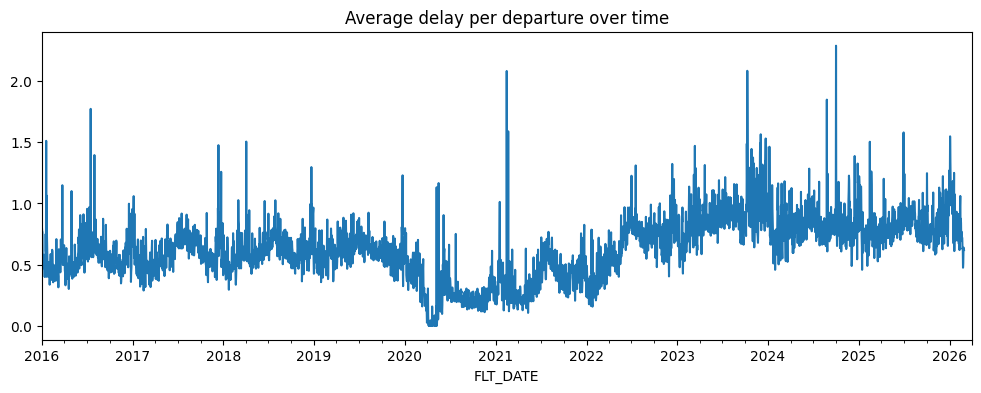

In [7]:
panel.groupby("FLT_DATE")["delay_per_dep"].mean().plot(figsize=(12, 4))
plt.title("Average delay per departure over time")
plt.show()

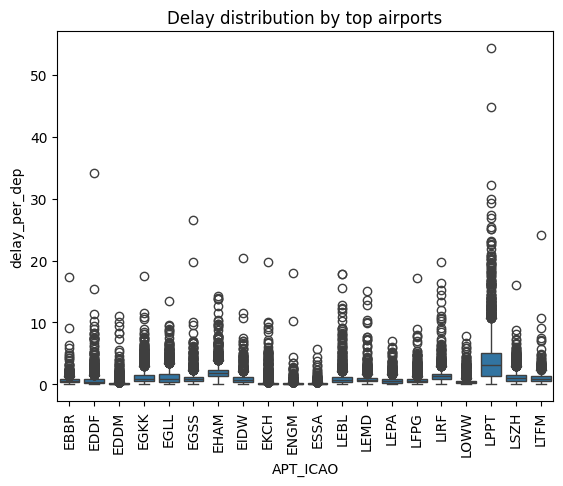

In [8]:
top_airports = (
    panel.groupby("APT_ICAO")["FLT_DEP_3"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
)

sns.boxplot(
    data=panel[panel["APT_ICAO"].isin(top_airports)],
    x="APT_ICAO",
    y="delay_per_dep"
)

plt.xticks(rotation=90)
plt.title("Delay distribution by top airports")
plt.show()

## 6. Build Classification Target


In [9]:
panel = panel.sort_values(["APT_ICAO","FLT_DATE"]).reset_index(drop=True)

panel["thresh"] = (
    panel.groupby("APT_ICAO")["delay_per_dep"]
    .transform(lambda s: s.shift(1).rolling(365, min_periods=60).quantile(0.75))
)

panel["y_reg"] = panel["delay_per_dep"]
panel["y_clf"] = (panel["delay_per_dep"] >= panel["thresh"]).astype("float")

panel.loc[
    panel["delay_per_dep"].isna() | panel["thresh"].isna(),
    "y_clf"
] = np.nan

## 7. Feature Engineering


In [10]:
df = panel.copy()
df = df[df["FLT_DEP_3"].fillna(0) >= MIN_DEPARTURES].copy()

In [11]:
df["cal_dow"] = df["FLT_DATE"].dt.dayofweek
df["cal_month"] = df["FLT_DATE"].dt.month
df["cal_week"] = df["FLT_DATE"].dt.isocalendar().week.astype(int)
df["cal_quarter"] = df["FLT_DATE"].dt.quarter
df["cal_is_weekend"] = (df["cal_dow"] >= 5).astype(int)
df["cal_is_month_start"] = df["FLT_DATE"].dt.is_month_start.astype(int)
df["cal_is_month_end"] = df["FLT_DATE"].dt.is_month_end.astype(int)

In [12]:
g = df.groupby("APT_ICAO", group_keys=False)

for lag in [1, 7, 14, 28]:
    df[f"lag_delay_per_dep_{lag}d"] = g["delay_per_dep"].shift(lag)
    df[f"lag_delay per dep_{lag}d"] = g["delay_per_dep"].shift(lag)


In [13]:
for window in [7, 30]:
    shifted_delay = g["delay_per_dep"].shift(1)
    shifted_dep = g["FLT_DEP_3"].shift(1)

    df[f"roll_delay_mean_{window}_d"] = (
        shifted_delay.groupby(df["APT_ICAO"])
        .rolling(window, min_periods=max(2, window // 2))
        .mean()
        .reset_index(level=0, drop=True)
    )

    df[f"roll_delay_std_{window}_d"] = (
        shifted_delay.groupby(df["APT_ICAO"])
        .rolling(window, min_periods=max(2, window // 2))
        .std()
        .reset_index(level=0, drop=True)
    )

    df[f"roll_dep_mean_{window}_d"] = (
        shifted_dep.groupby(df["APT_ICAO"])
        .rolling(window, min_periods=max(2, window // 2))
        .mean()
        .reset_index(level=0, drop=True)
    )

In [14]:
state_yday = (
    df.groupby(["STATE_NAME", "FLT_DATE"])["delay_per_dep"]
    .median()
    .reset_index()
    .rename(columns={"delay_per_dep": "net_state_med_delay"})
)

state_yday["FLT_DATE"] = state_yday["FLT_DATE"] + pd.Timedelta(days=1)

df = df.merge(state_yday, on=["STATE_NAME", "FLT_DATE"], how="left")

In [15]:
df = df[df["y_clf"].notna()].copy()
df["y_clf"] = df["y_clf"].astype(int)

## 8. Train/Val/Test Split


In [16]:
train = df[df["FLT_DATE"] <= "2022-12-31"].copy()
val = df[(df["FLT_DATE"] > "2022-12-31") & (df["FLT_DATE"] <= "2023-12-31")].copy()
test = df[df["FLT_DATE"] > "2023-12-31"].copy()

print(train.shape)
print(val.shape)
print(test.shape)

(164713, 42)
(27427, 42)
(62676, 42)


## 9. Select Features


In [17]:
drop_cols = [
    "y_clf", "y_reg", "thresh", "delay_per_dep",
    "DLY_ATC_PRE_3", "DLY_ATC_PRE_2",
    "FLT_DATE", "APT_NAME", "MONTH_MON",
]

feature_cols = []

for c in df.columns:
    if c not in drop_cols:
        feature_cols.append(c)

x_train = train[feature_cols]
y_train = train["y_clf"]

x_val = val[feature_cols]
y_val = val["y_clf"]

x_test = test[feature_cols]
y_test = test["y_clf"]


In [18]:
categorical_features = ["APT_ICAO", "STATE_NAME"]
categorical_features = [c for c in categorical_features if c in feature_cols]

numeric_features = [
    c for c in feature_cols
    if c not in categorical_features and pd.api.types.is_numeric_dtype(df[c])
]

## 10. Preprocessing Pipelines


In [19]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]),numeric_features),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
    ]
)

In [20]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ]), categorical_features),
    ]
)

## 11. Training Baselines and Models


In [21]:
models = {
    "dummy": Pipeline([
        ("pre", tree_preprocessor),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]),
    "logreg": Pipeline([
        ("pre", linear_preprocessor),
        ("model", LogisticRegression(max_iter=300, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "decision_tree": Pipeline([
        ("pre", tree_preprocessor),
        ("model", DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "random_forest": Pipeline([
        ("pre", tree_preprocessor),
        ("model", RandomForestClassifier(n_estimators=200, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "hist_gb": Pipeline([
        ("pre", tree_preprocessor),
        ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
    ]),
}

In [22]:
results = []

for name, model in models.items():
    model.fit(x_train, y_train)
    proba = model.predict_proba(x_val)[:,1]

    results.append({
        "model": name,
        "roc_auc": roc_auc_score(y_val, proba),
        "pr_auc": average_precision_score(y_val, proba),
        "brier": brier_score_loss(y_val, proba),
    })

pd.DataFrame(results).sort_values("roc_auc", ascending=False)

,model,roc_auc,pr_auc,brier
1,logreg,0.672984,0.557176,0.275999
4,hist_gb,0.668530,0.558624,0.213352
3,random_forest,0.649436,0.524420,0.212793
2,decision_tree,0.605573,0.474758,0.288931
0,dummy,0.500000,0.324498,0.324498


## 12. Choosing best threshold
